ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [1]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [2]:
 df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [3]:
 df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [4]:
 df.shape

(8950, 18)

**Check basic information about the dataset using `info()`.**

In [5]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [6]:
 df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [7]:
 df.drop('CUST_ID', axis=1, inplace=True)

**Check the missing values in each column.**

In [8]:
 df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [9]:
 df.fillna(df.mean(), inplace=True)

**Check the missing values again to make sure they were handled.**

In [10]:
 df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

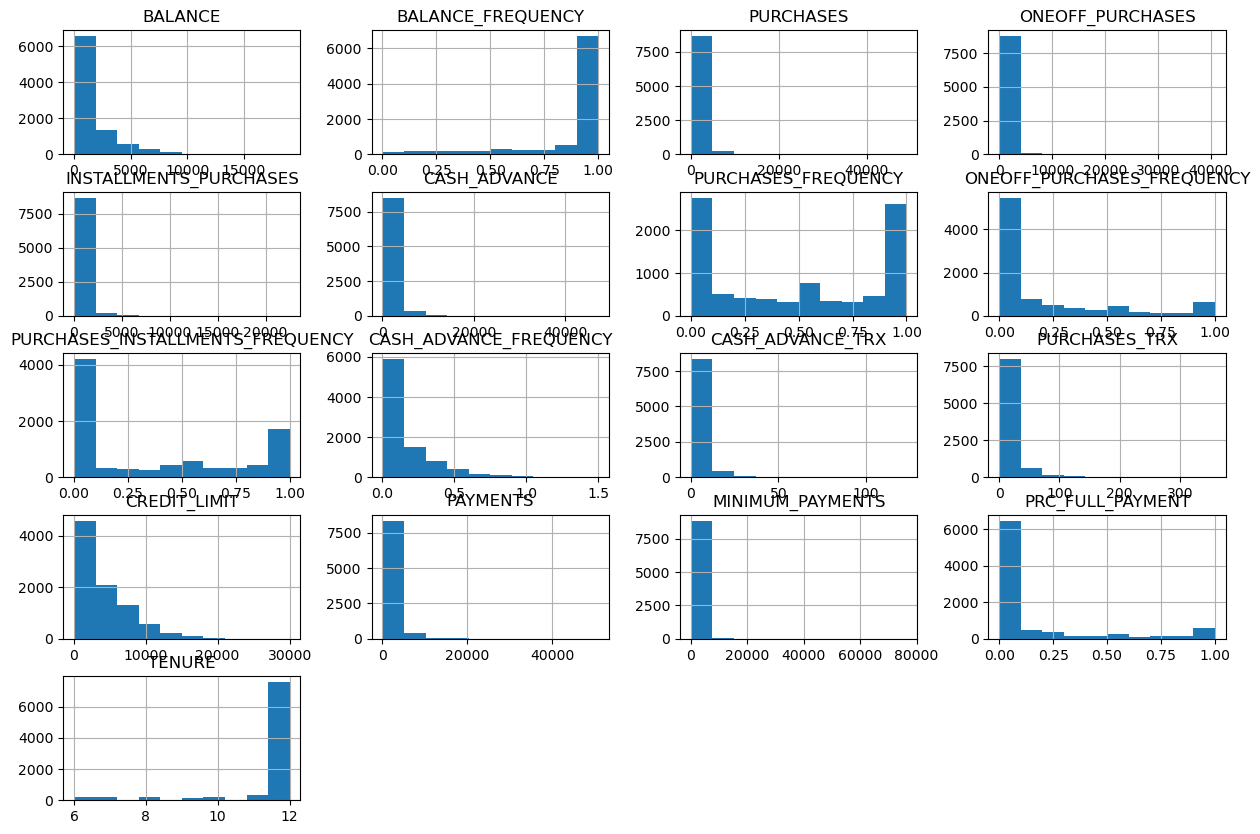

In [11]:
 df.hist(figsize=(15,10))
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

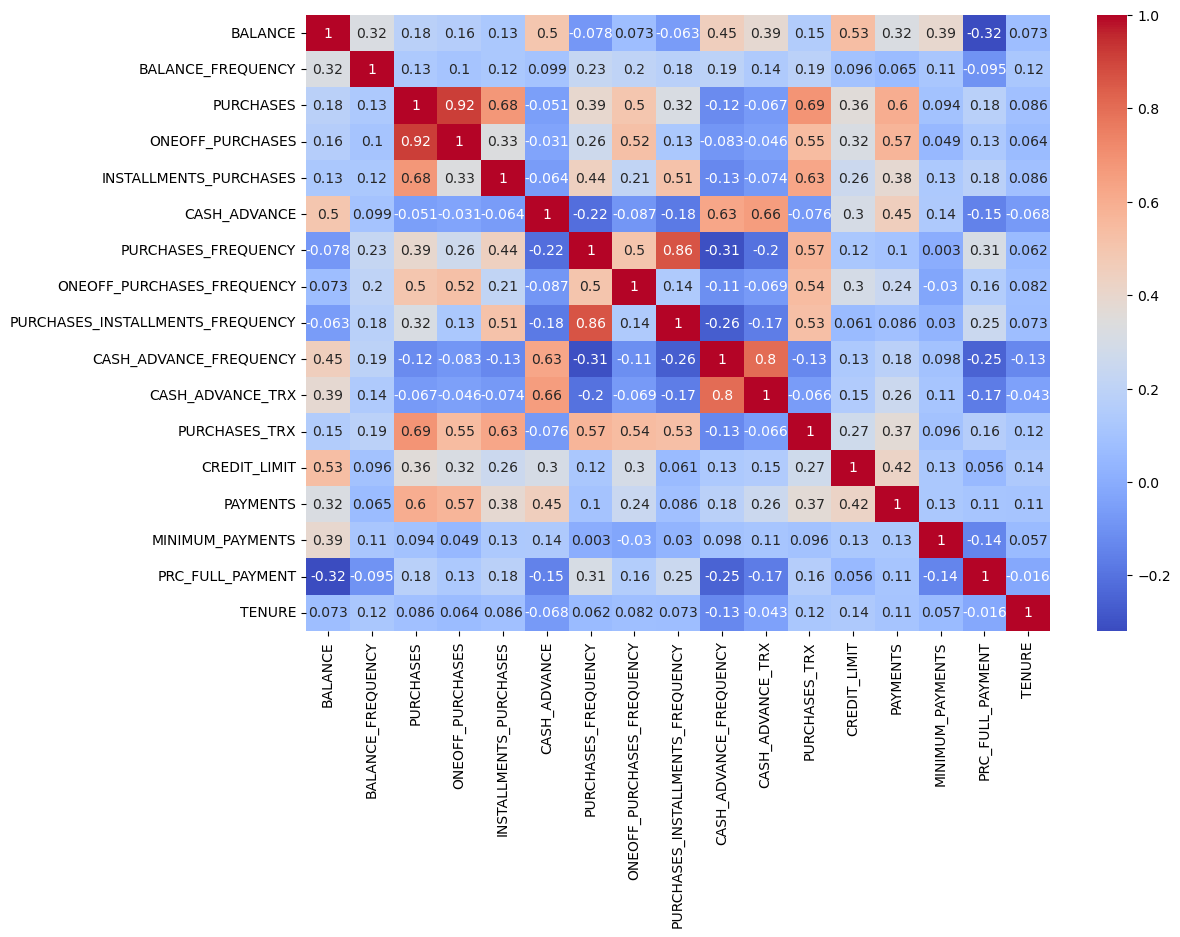

In [12]:
 plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

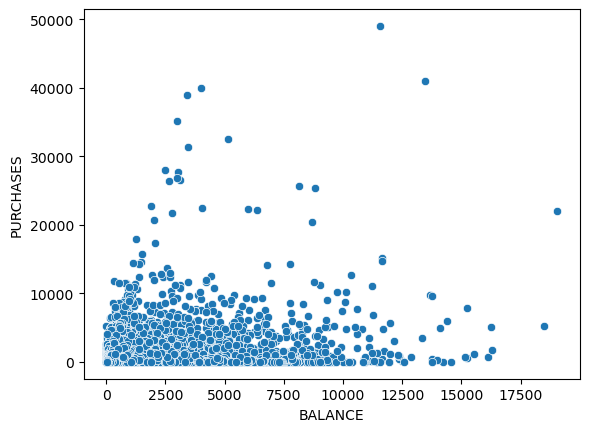

In [13]:
 sns.scatterplot(x='BALANCE', y='PURCHASES', data=df)
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

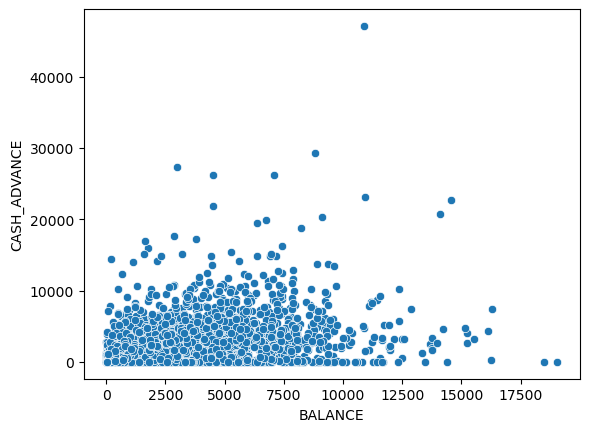

In [14]:
 sns.scatterplot(x='BALANCE', y='CASH_ADVANCE', data=df)
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [15]:
 scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [16]:
 inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

**Plot the elbow curve.**

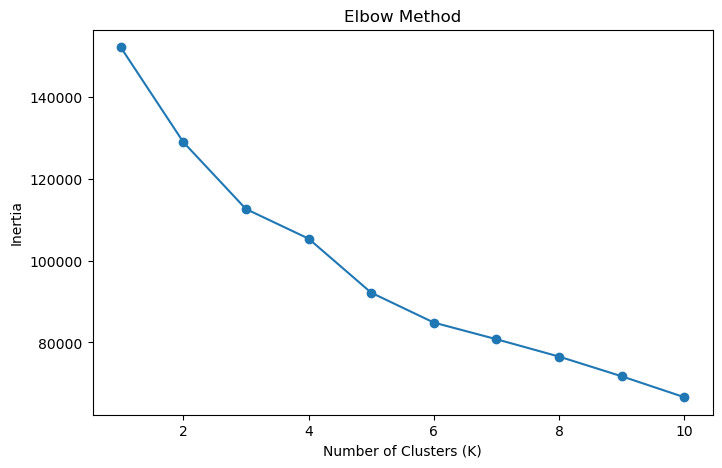

In [17]:
 plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [18]:
 silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

**Plot the silhouette scores.**

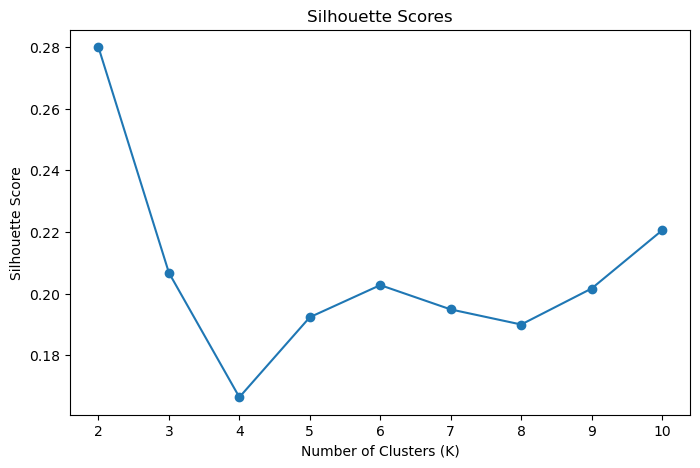

In [19]:
 plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.show()

**Create a table showing each K value and its silhouette score.**

In [20]:
 silhouette_table = pd.DataFrame({
    'K': range(2,11),
    'Silhouette Score': silhouette_scores
})

silhouette_table

,K,Silhouette Score
0,2,0.279913
1,3,0.206761
2,4,0.166392
3,5,0.192346
4,6,0.202755
5,7,0.194870
6,8,0.189973
7,9,0.201655
8,10,0.220518


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [21]:
 kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [22]:
 df['Cluster'] = clusters

**Check the first five rows after adding the cluster labels.**

In [23]:
 df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [24]:
 cluster_summary = df.groupby('Cluster').mean()

cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,4545.974404,0.968555,578.629243,363.840483,214.870685,4513.943197,0.286012,0.136806,0.187025,0.483019,14.266720,8.379533,7469.463776,3587.216766,2086.889127,0.036493,11.388396
1,943.444730,0.789577,302.146789,207.553551,94.891652,530.425643,0.244520,0.091332,0.147935,0.104059,1.913578,3.981794,3221.355927,927.922179,576.084073,0.093135,11.396140
2,1288.676491,0.968227,2185.116559,1239.540251,945.965035,235.200775,0.926645,0.389155,0.747676,0.043082,0.840635,32.730476,5164.938528,2168.096589,799.508527,0.287573,11.743492


**Check how many customers are in each cluster.**

In [25]:
df['Cluster'].value_counts() 

Cluster
1    4559
2    3150
0    1241
Name: count, dtype: int64

## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

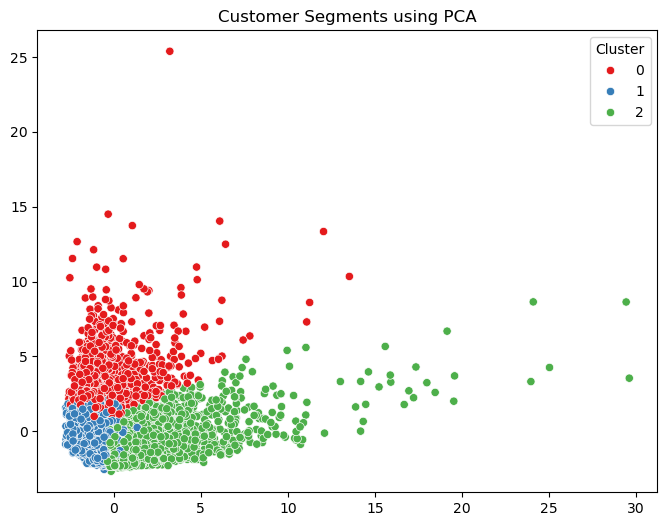

In [26]:
 pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title('Customer Segments using PCA')

plt.show()

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

1. Why is this an unsupervised learning problem?

2. Why did we remove the `CUST_ID` column?

3. Which columns had missing values?

4. How did you handle the missing values?

5. Why is scaling important before applying K-Means?

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.

7. Based on the cluster summary table, describe each customer segment in your own words.

8. Which cluster may represent high-value customers?

9. Which cluster may represent customers who rely more on cash advance?

10. How can a company use these clusters for marketing strategy?

In [ ]:
1-This is an unsupervised learning problem because the dataset does not contain labeled output classes. The goal is to group customers into clusters based on their behavior and spending patterns.
2-We removed the CUST_ID column because it is only an identifier and does not provide useful information for clustering.
3-The columns that had missing values were MINIMUM_PAYMENTS and CREDIT_LIMIT.
4-The missing values were handled using mean imputation by replacing missing values with the mean of each column.
5-Scaling is important before applying K-Means because the algorithm is distance-based. Features with larger values could dominate the clustering process if the data is not scaled.
6-We chose the K value based on the elbow method and silhouette score. The elbow point showed where the distortion started decreasing slowly, while the silhouette score helped select the number of clusters with better separation and cohesion.
7-Each cluster represents a different type of customer behavior. Some clusters include customers with high balances and purchases, while others include customers with lower spending or higher cash advance usage.
8-The cluster with high balance, high purchases, and high credit usage may represent high-value customers.
9-The cluster with high CASH_ADVANCE values may represent customers who rely more on cash advances.
10-Companies can use these clusters to create targeted marketing strategies, provide personalized offers, improve customer satisfaction, and identify high-value or risky customers.